In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
from langgraph.graph import START, END, StateGraph, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from pydantic import BaseModel,Field
from typing import Annotated,Literal

from langchain.agents import create_agent
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage
from dotenv import load_dotenv
load_dotenv()


True

In [4]:
llm=ChatGroq(model="openai/gpt-oss-20b")

In [ ]:
class AgentState(MessagesState):
    query:str
    long_term_memory:str=""
    context:dict=Field(default={},description="Relevant information gathered for the current query")
    tools_response:list[dict]=Field(default=[],description="Response of tools after execution")
    next_actions:list=[]
    final_response:str=""

### Node 1-> Long_term memory recall for query

In [8]:
from langchain_core.runnables import RunnableConfig
from langgraph.store.base import BaseStore

In [9]:
def chat_node(state:MessagesState,config:RunnableConfig, *, store:BaseStore):
    user_id=config['configurable']['user_id']
    ns=("user",user_id,"details")

    items=store.search(ns)
    user_details="\n".join(it.value["data"] for it in items) if items else "empty"

    return {"long_term_memory":user_details}

### supervisor system prompt:

In [ ]:
SUPERVISOR_PROMPT:

### Node1 -> Context creator

In [ ]:
def context_manager(state:AgentState):
    return{
        
    }

SyntaxError: expected ':' (1213420097.py, line 1)

### Node->2 Tool executor

In [18]:
def web_search(query:str):
    """
    perform web searching in the basis of query.
    Args:
    query: search query (string)
    """
    return f"search results for {query}"

tools = [
    web_search
]
def execute(action):
    return f"action : {action} executed succesfully"

def tools_execution_node(state:AgentState):
    actions=state.next_actions
    state.tools_response=[]
    for action in actions:
        state.tools_response.append({action:execute(action)})

    return state

In [9]:
SUPERVISOR_PROMPT = """
You are the supervisor of an AI agent.

Your responsibility is to solve the user's query by deciding whether
additional tool execution is required.

Rules:

1. Understand the user's query.
2. Use the available tools when external information or computation is required.
3. Do not use a tool when the information already available in the state
   is sufficient.
4. After receiving tool results, reassess the problem.
5. If enough information is available to answer the user, do not call
   another tool.
6. Never invent tool results.
7. Give a final answer only when sufficient information is available.

User query:
{query}

Conversation history:
{messages}

Current context:
{context}

"""

In [ ]:
class SupervisorResponse(BaseModel):
    action:Literal["tool_execution","final_response"]
    next_actions:list=Field(default=[],description="What tools/actions should be performed next")

### Conditional node->route (tool,final_response)

In [23]:
def route(state:SupervisorResponse)->Literal["tool_execution","final_response"]:
    return state.action

### Node3-> final_response

In [24]:
def final_response_node(state:SupervisorResponse):
    return{
        "final_response":state.final_response
    }

### Node 4-> supervisor

In [25]:
supervisor_llm=llm.bind_tools(tools=tools),
def supervisor_node(state:AgentState):
    system_message=SystemMessage(
        content=SUPERVISOR_PROMPT.format(
            query=state.query,
            messages=state.messages,
            context=state.context,
        )
    )
    response=supervisor_llm.invoke(
        system_message
    )
    
    return
    

### Graph creation

In [27]:
graph=StateGraph(AgentState)

graph.add_node("context_manager",context_manager_node)
graph.add_node("supervisor",supervisor_node)
graph.add_node("final_response",final_response_node)
graph.add_node("tool_execution",tools_execution_node)

graph.add_edge(START,"context_manager")
graph.add_edge("context_manager","supervisor")
graph.add_conditional_edges("supervisor",route)
graph.add_edge("final_response",END)
graph.add_edge("tool_execution","supervisor")

graph=graph.compile()

## Graph

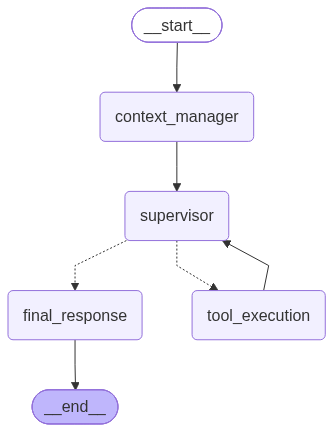

In [29]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

## testing